# Masking Example

This tutorial illustrates methods to help with masking data.

## Load Data
 
First, let's load the pain data for this example.

In [ ]:
from nltools.datasets import fetch_pain

data = fetch_pain()

## Apply_Mask

Spherical masks can be created using the create_sphere function.
It requires specifying a center voxel and the radius of the sphere.

/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/nilearn/image/resampling.py:297: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images


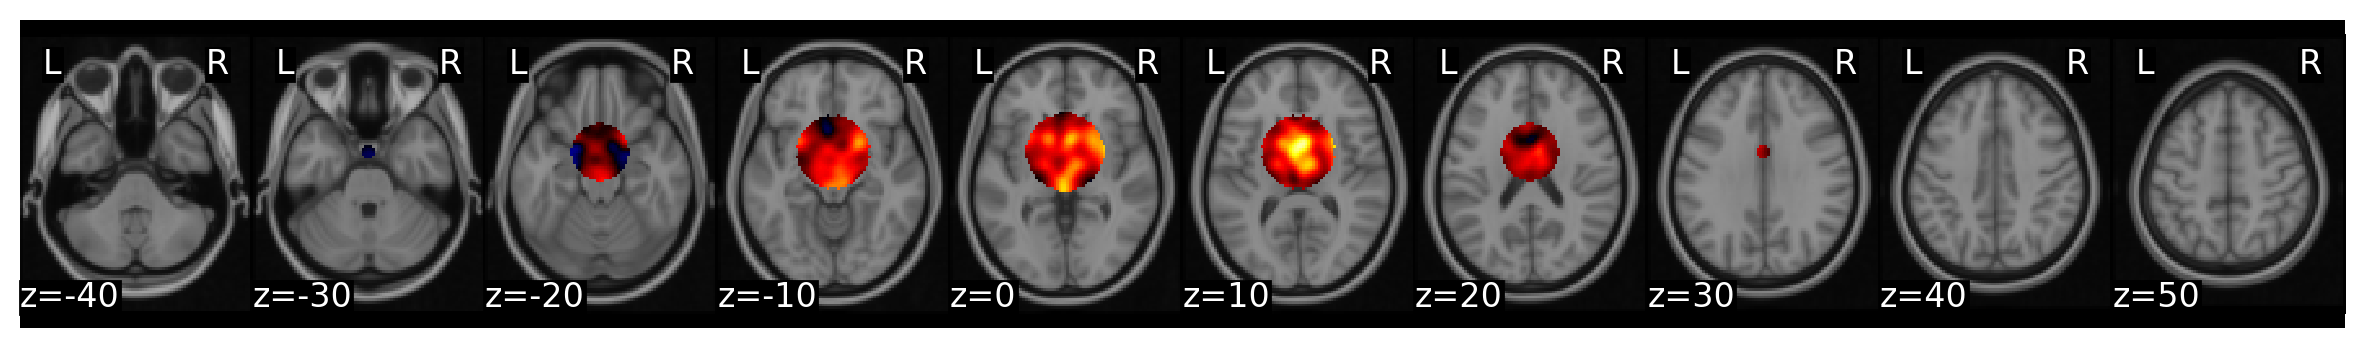

In [2]:
from nltools.mask import create_sphere

mask = create_sphere([0, 0, 0], radius=30)
masked_data = data.apply_mask(mask)
masked_data.mean().plot()

## Extract Mean Within ROI

We can easily calculate the mean within an ROI for each image within a 
Brain_Data() instance using the extract_roi() method.

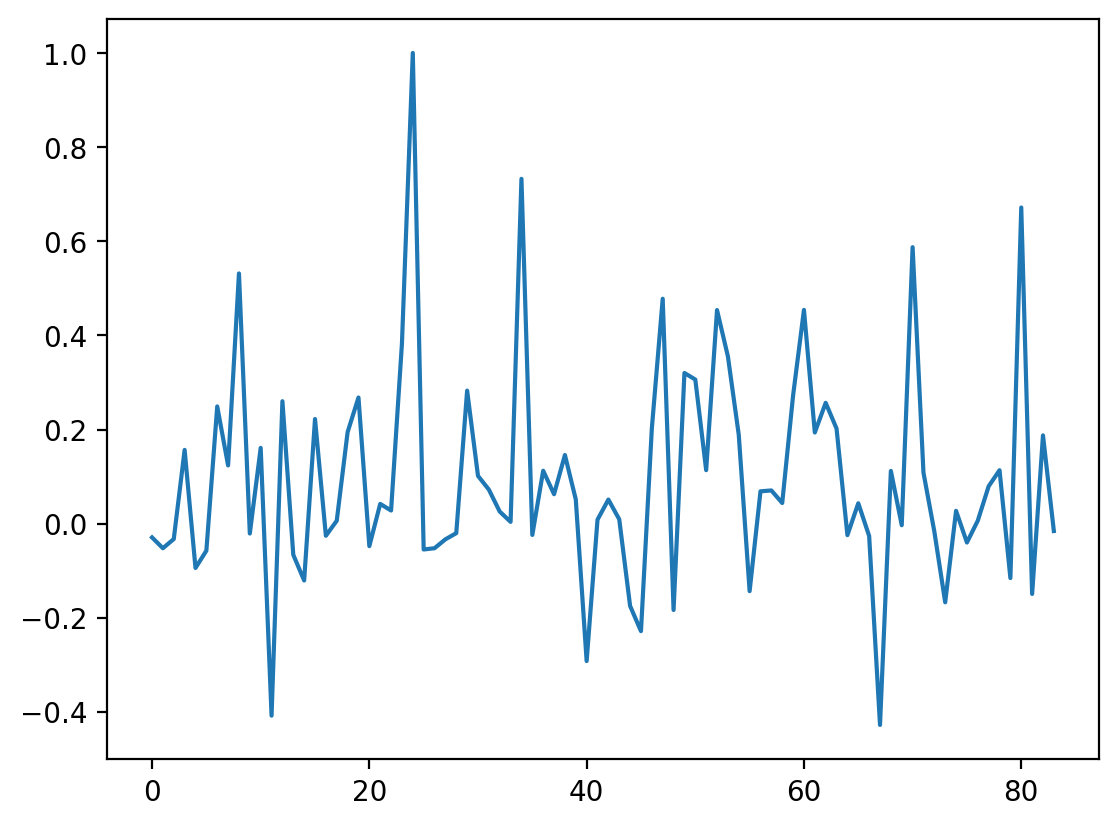

In [3]:
import matplotlib.pyplot as plt

mean = data.extract_roi(mask)
plt.plot(mean)

## Expand and Contract ROIs

Some masks have many ROIs indicated by a unique ID.  It is possible to
expand these masks into separate ROIs and also collapse them into a single
image again.  Here we will demonstrate on a k=50 parcellation hosted on
http://neurovault.org.

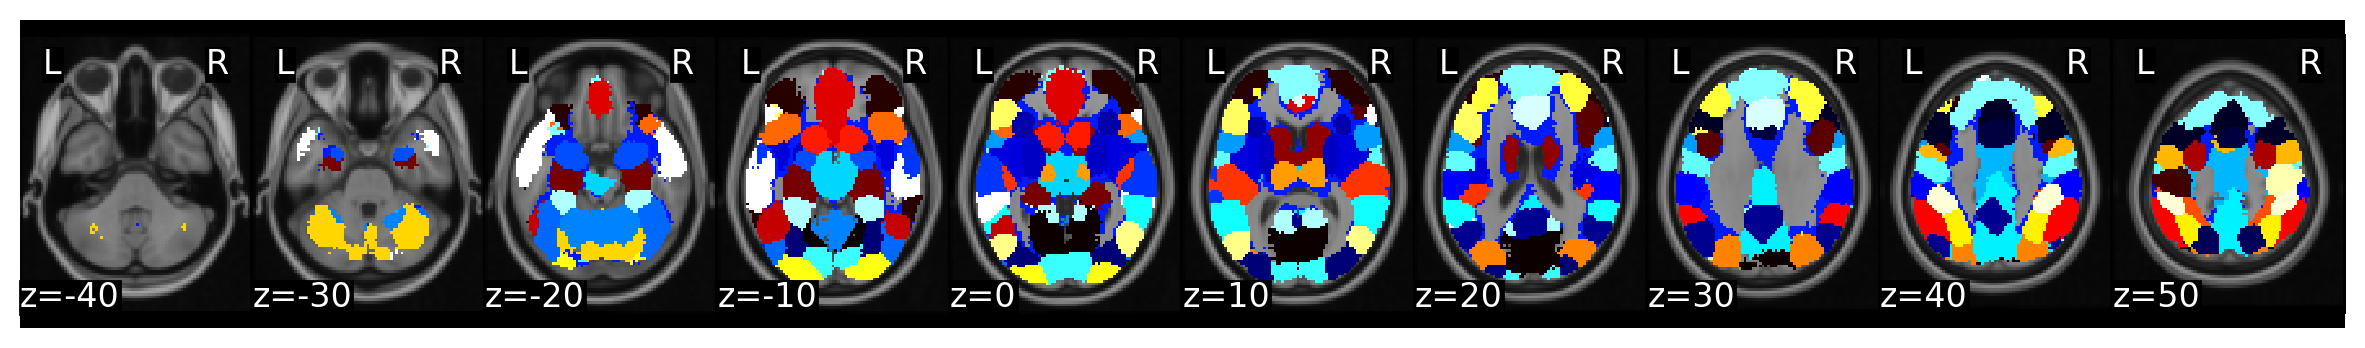

In [4]:
from nltools.mask import expand_mask, collapse_mask
from nltools.data import Brain_Data

mask = Brain_Data('http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz')
mask.plot()

We can expand this mask into 50 separate regions

/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/nilearn/masking.py:979: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)


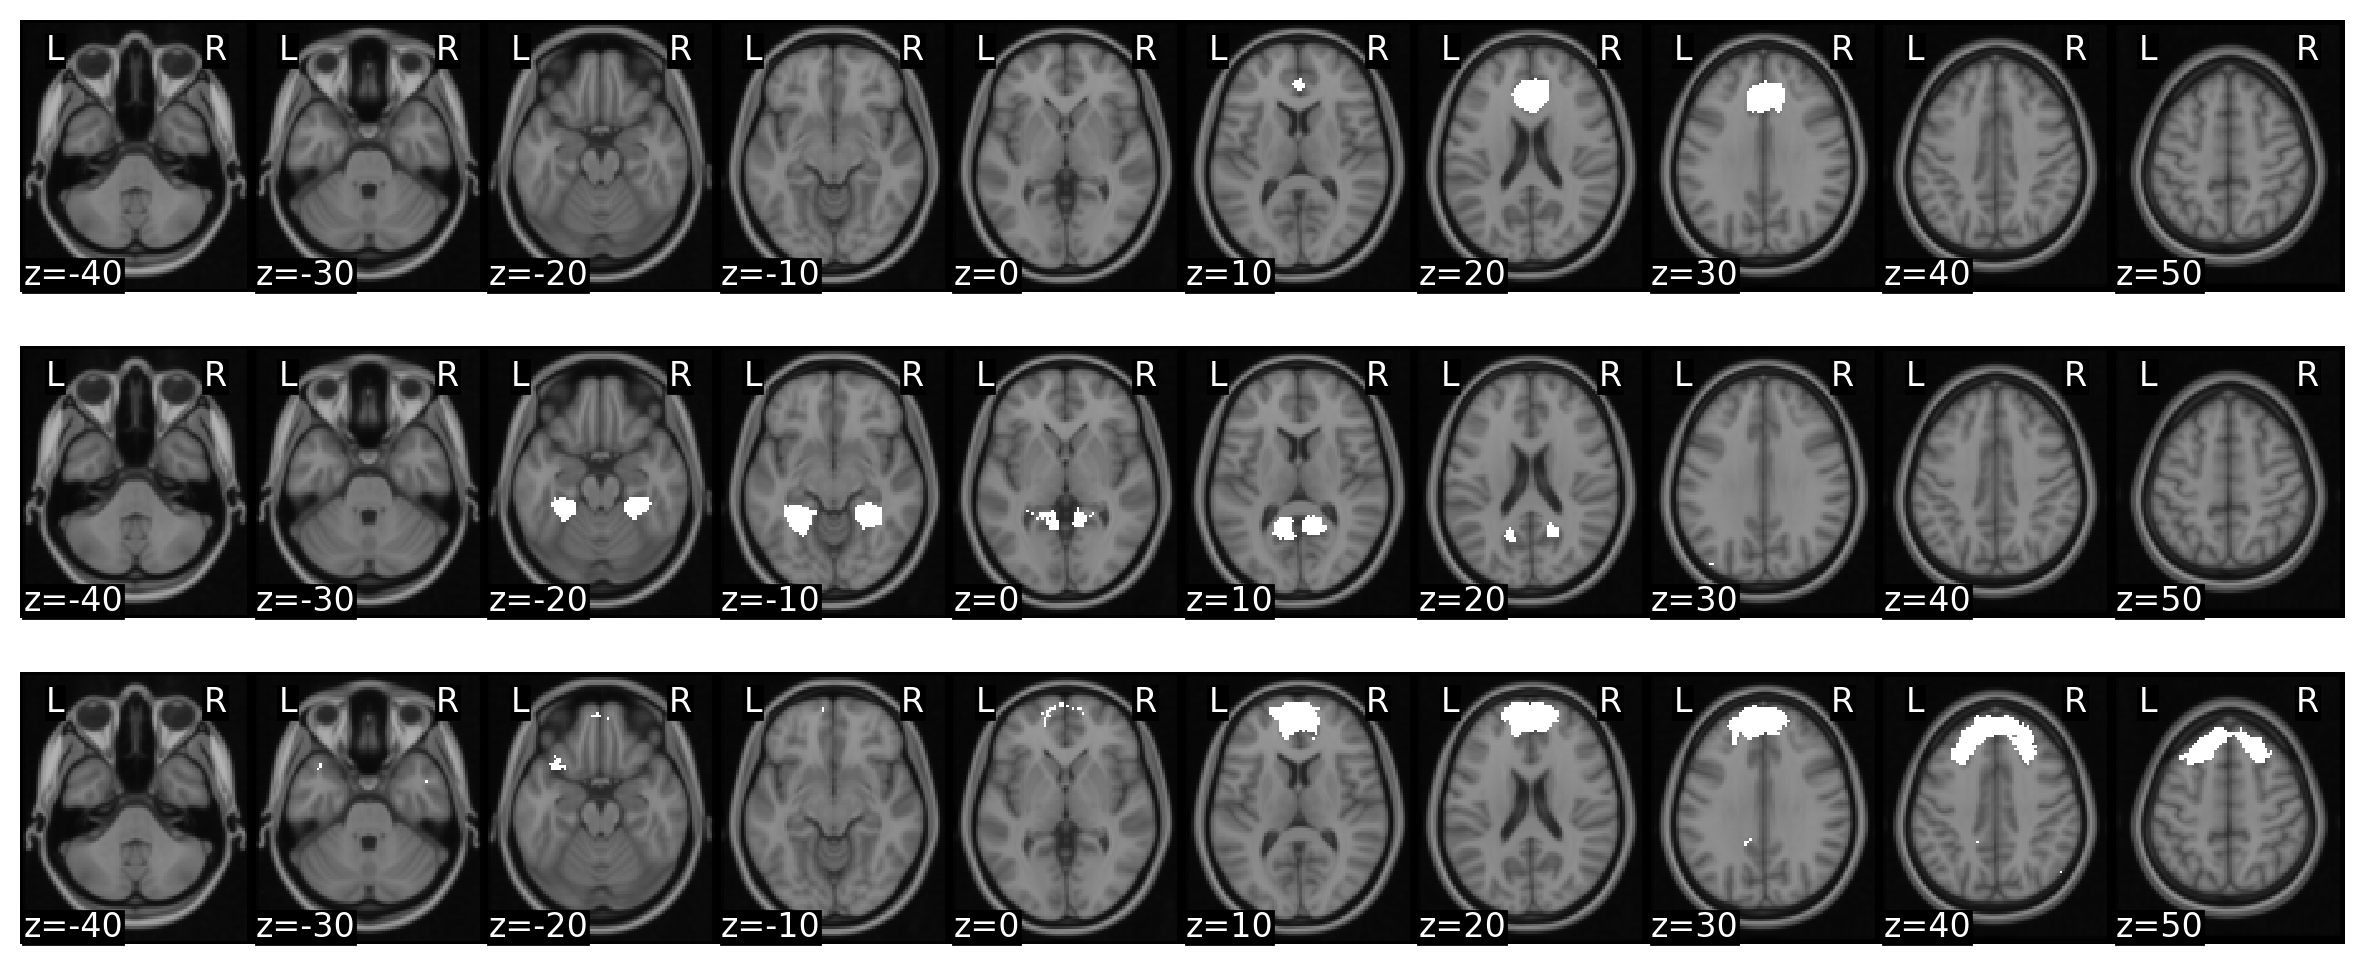

In [5]:
mask_x = expand_mask(mask)
mask_x[:3].plot()

We can collapse these 50 separate regions as unique values in a single image

/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/nilearn/masking.py:979: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)
/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/nilearn/masking.py:979: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)


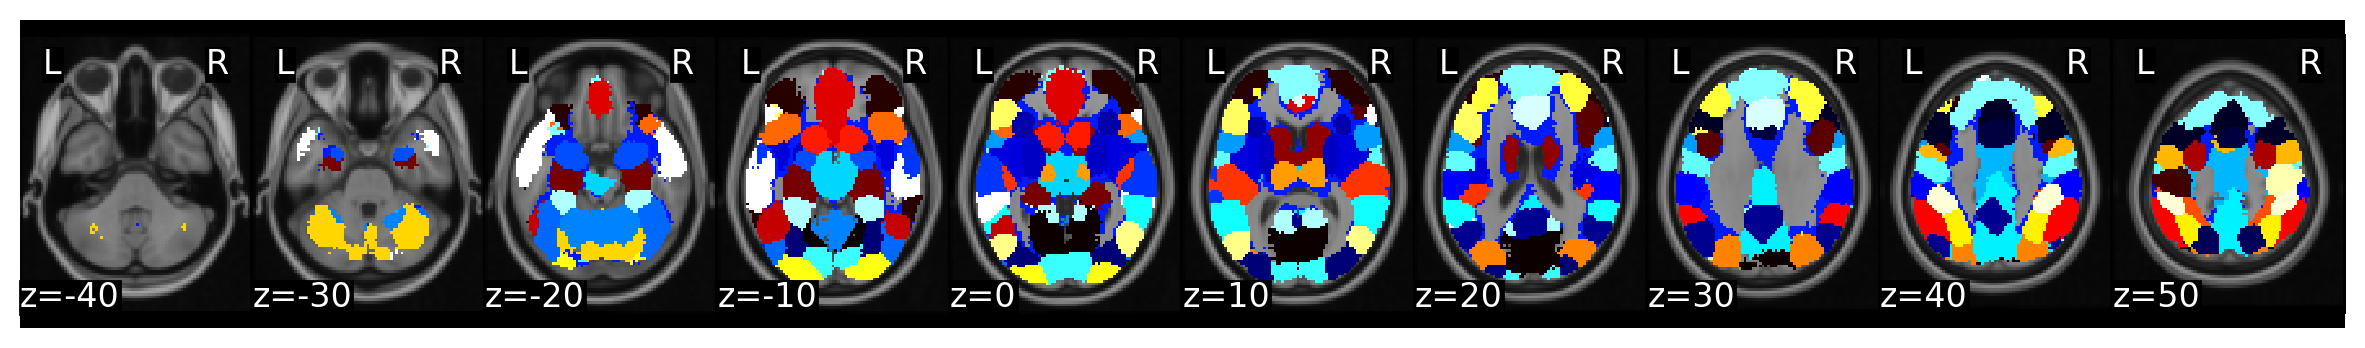

In [6]:
mask_c = collapse_mask(mask_x)
mask_c.plot()

## Threshold and Regions

Images can be thresholded using an arbitrary cutoff or a percentile using the 
threshold method.  Here we calculate the mean of the high pain images and
threshold using the 95 percentile.

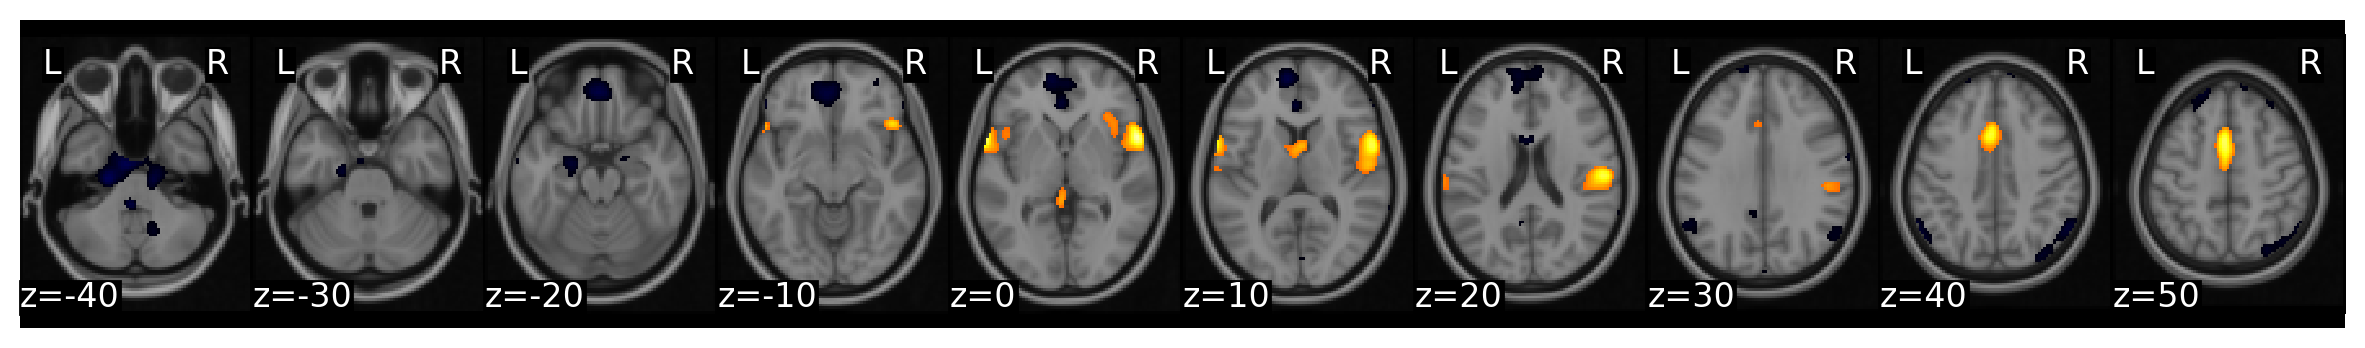

In [7]:
high = data[data.X['PainLevel']==3]
high.mean().threshold(lower='2.5%', upper='97.5%').plot()

We might be interested in creating a binary mask from this threshold.

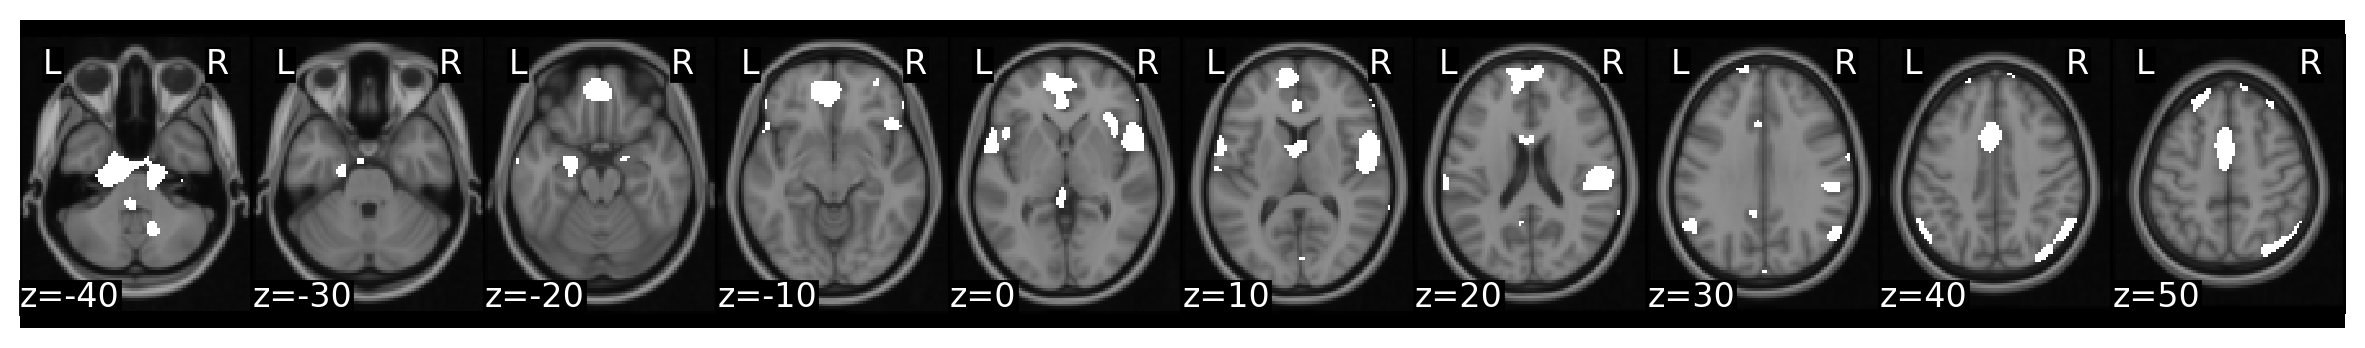

In [8]:
mask_b = high.mean().threshold(lower='2.5%', upper='97.5%',binarize=True)
mask_b.plot()

We might also want to create separate images from each contiguous ROI.

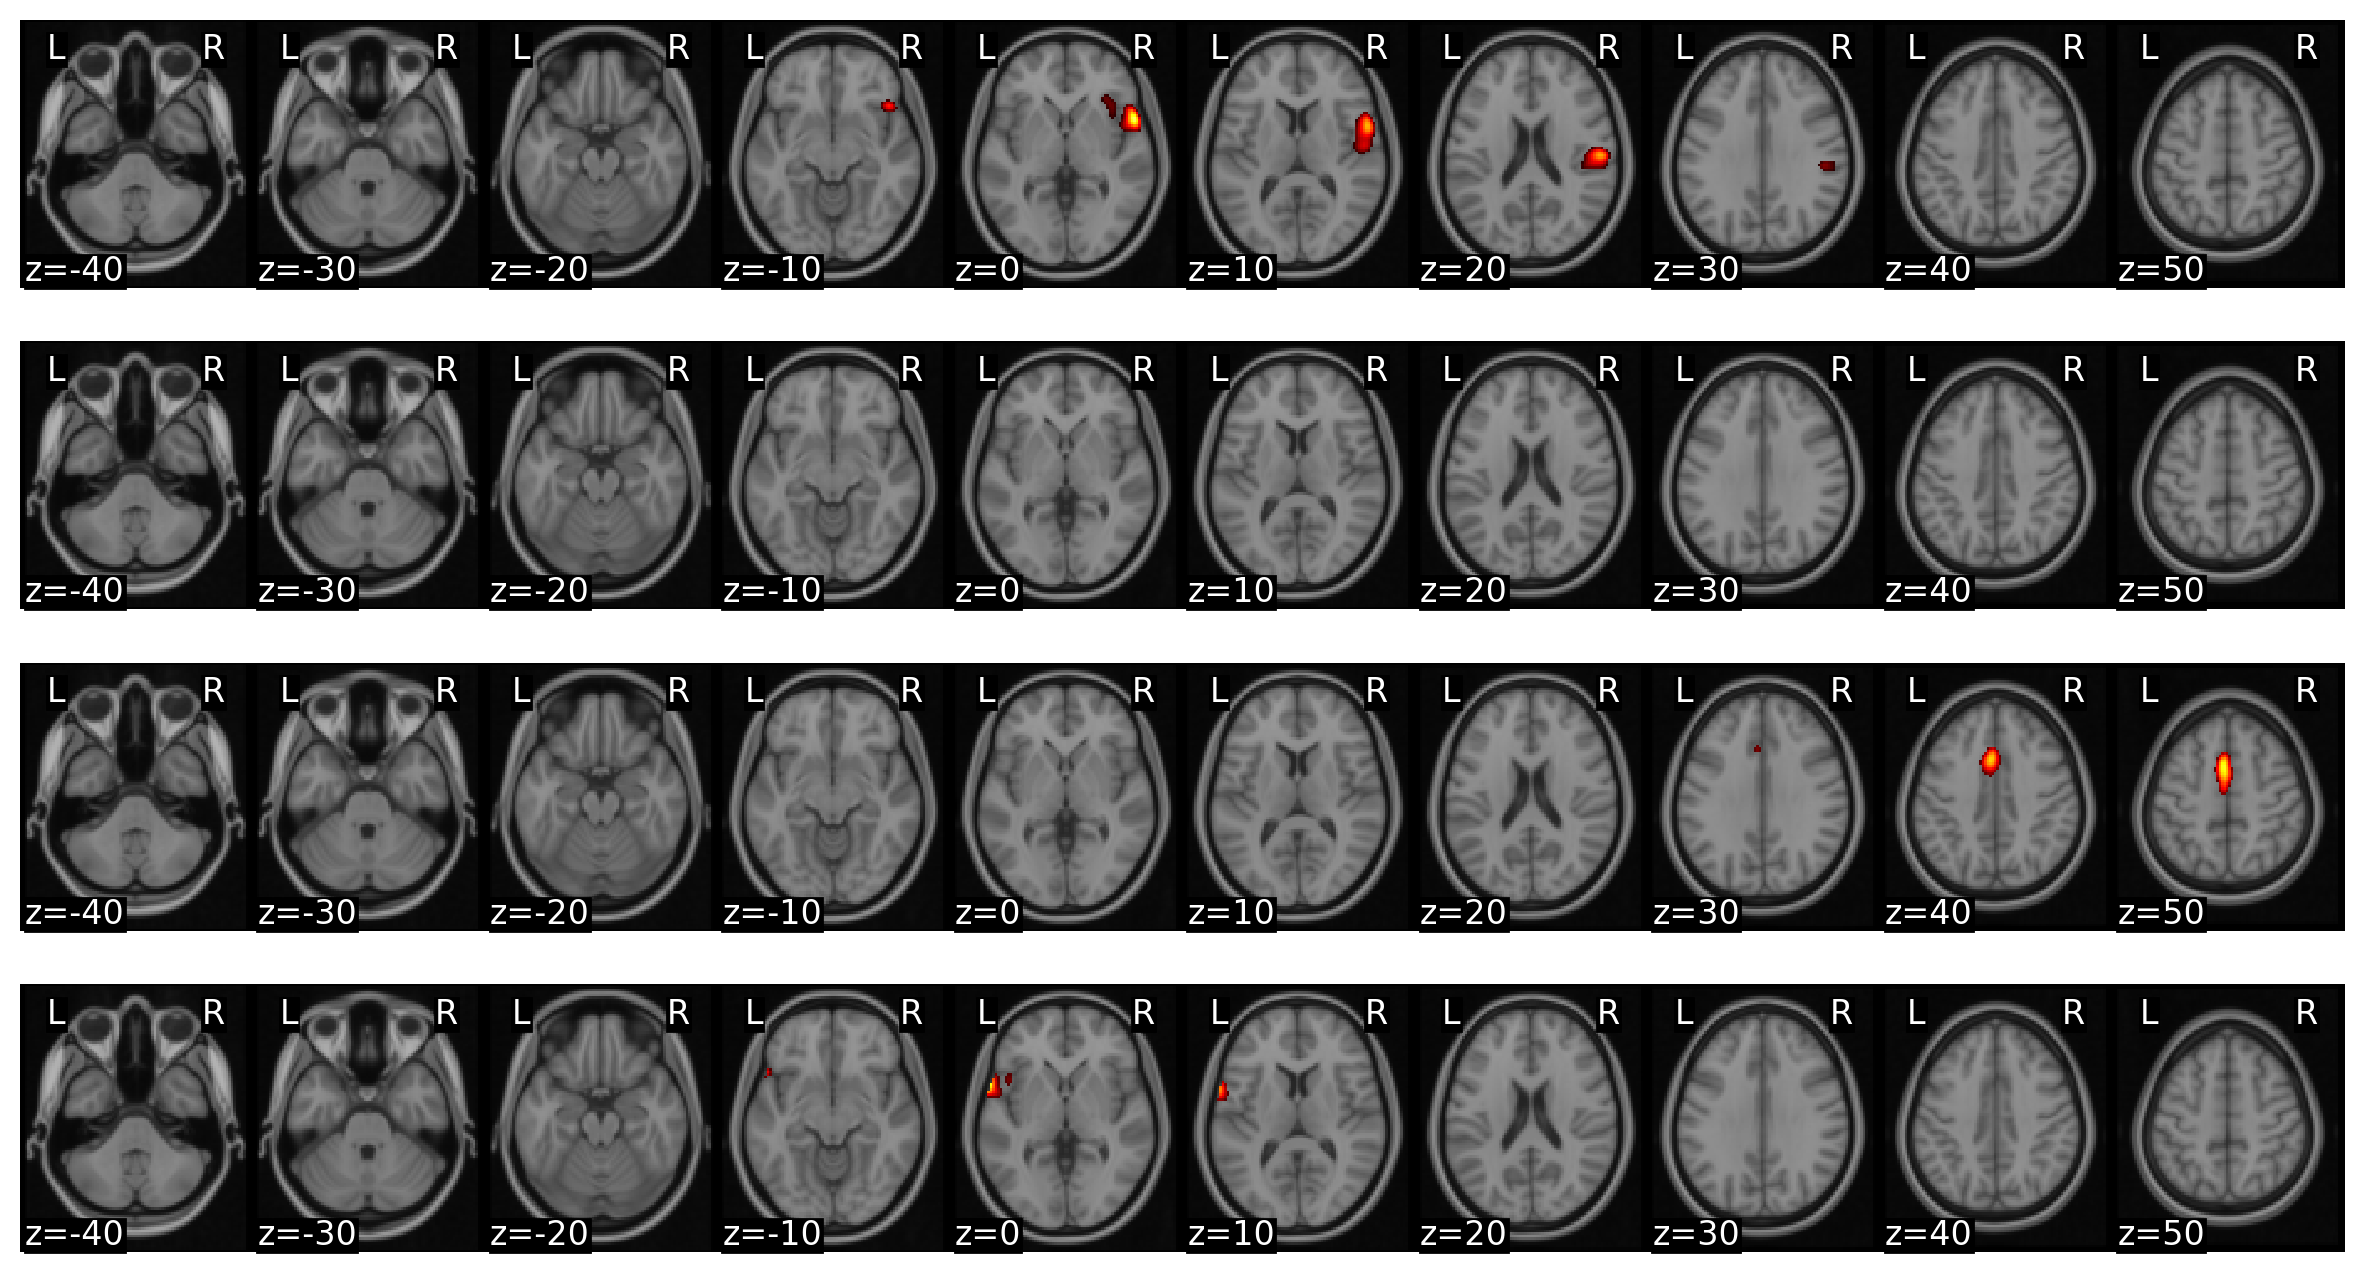

In [9]:
region = high.mean().threshold(lower='2.5%', upper='97.5%').regions()
region.plot()

Finally, we can perform operations on ROIs from a mask and then convert them
back into a Brain_Data instance. In this example, let's compute a linear contrast
of increasing pain for each each participant. Then, let's compute functional 
connectivity across participants within each ROI and calculate the degree 
centrality of each ROI after arbitrarily thresholding the connectivity matrix.
We can then convert each ROIs degree back into a Brain_Data instance to help
visualize which regions are more central in this analysis.

/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/nilearn/masking.py:979: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)


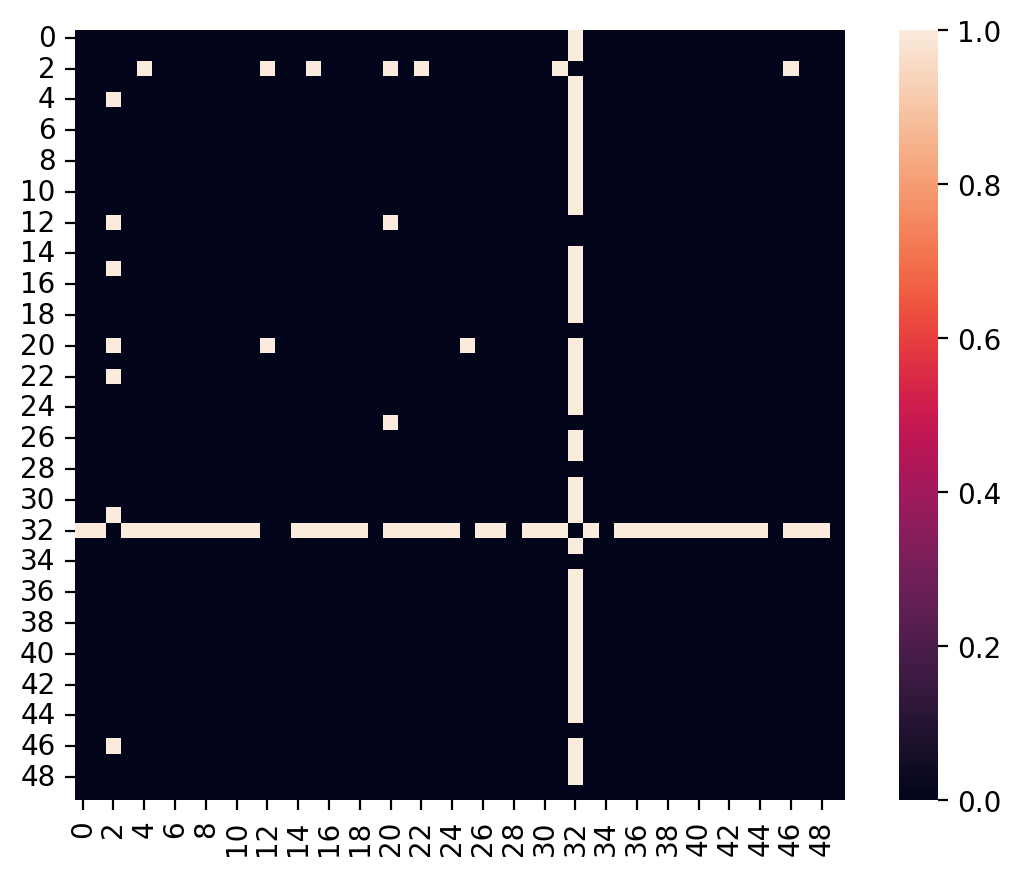

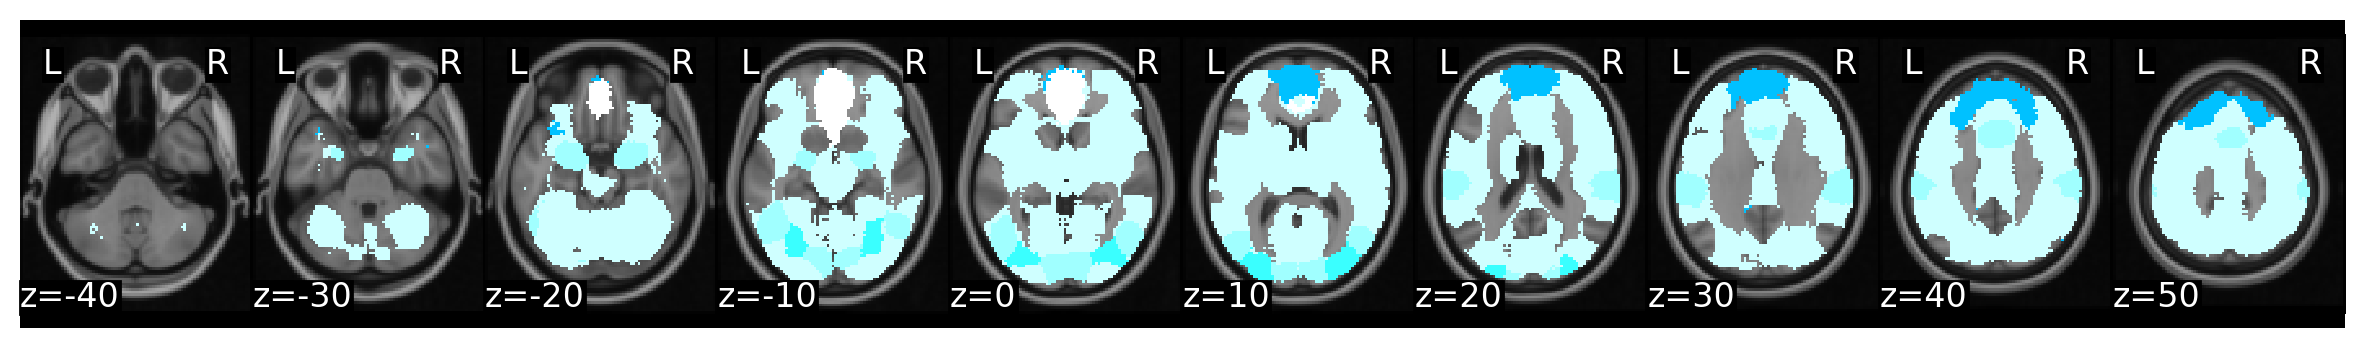

In [10]:
from sklearn.metrics import pairwise_distances
from nltools.data import Adjacency
from nltools.mask import roi_to_brain
import pandas as pd
import numpy as np

sub_list = data.X['SubjectID'].unique()

# perform matrix multiplication to compute linear contrast for each subject
lin_contrast = []
for sub in sub_list:
    lin_contrast.append(data[data.X['SubjectID'] == sub] * np.array([1, -1,  0])) 

# concatenate list of Brain_Data instances into a single instance
lin_contrast = Brain_Data(lin_contrast) 

# Compute correlation distance between each ROI
dist = Adjacency(pairwise_distances(lin_contrast.extract_roi(mask), metric='correlation'), matrix_type='distance')

# Threshold functional connectivity and convert to Adjacency Matrix. Plot as heatmap
dist.threshold(upper=.4, binarize=True).plot()

# Convert Adjacency matrix to networkX instance
g = dist.threshold(upper=.4, binarize=True).to_graph()

# Compute degree centrality and convert back into Brain_Data instance.
degree_centrality = roi_to_brain(pd.Series(dict(g.degree())), mask_x)

degree_centrality.plot()